#### Create Pipeline

To make a geospatial live service, we have to make sure the inference input is exactly the same as training's dataset.

This standardization solves and bridges live data ingestion with various models input specification. NO MORE GLUE CODE!

The created pipeline can be used to create training dataset, granted you already have the anchor like semantic segmentation label for example.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch

from geosave_engine.geodata import GeoTile
from geosave_engine.geodata.features import compute_ndvi, compute_scl_mask
from geosave_engine.geodata.pipeline import GeoPipeline
from geosave_engine.geodata.stac import StacClient, StacSource


L2A_SPECTRAL_BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
L2A_BANDS = [*L2A_SPECTRAL_BANDS, "SCL"]

# ESA Sen2Cor's own SCL legend (Sen2Cor ATBD) — same class/color scheme SCL
# ships with everywhere (QGIS default style, ESA docs, etc).
SCL_CLASS_MAP = {
    0: "no_data", 1: "saturated_defective", 2: "dark_area", 3: "cloud_shadow",
    4: "vegetation", 5: "bare_soil", 6: "water", 7: "unclassified",
    8: "cloud_medium_prob", 9: "cloud_high_prob", 10: "thin_cirrus", 11: "snow_ice",
}
SCL_COLOR_MAP = {
    0: "#000000", 1: "#ff0000", 2: "#2f2f2f", 3: "#643200",
    4: "#00a600", 5: "#ffe65a", 6: "#0000ff", 7: "#808080",
    8: "#c0c0c0", 9: "#ffffff", 10: "#66ccff", 11: "#ff66ff",
}

In [6]:
class Pipeline(GeoPipeline):
    """Sentinel-2 L2A imagery + Scene Classification Layer + SCL-derived cloud mask for one anchor.

    Practical alternative to `data_pipeline_l1c.Pipeline`: L2A is already
    atmospherically corrected (surface reflectance, not TOA) and ships its
    own per-pixel Scene Classification Layer, so cloud/shadow/snow masking
    is a lookup (`compute_scl_mask`) instead of running s2cloudless/CDI/B10
    detectors — faster ingest, no L1C pixel artifacting, and Planetary
    Computer serves it with signed URLs, no CDSE credentials needed. Kept
    separate from the L1C pipeline (not a drop-in replacement) since that
    one exists specifically to reproduce the DynamicWorld paper's own L1C +
    s2cloudless/CDI/B10 methodology.
    """

    def __init__(self) -> None:
        self.client = StacClient.planetary_computer()

    def sources(self) -> dict[str, StacSource]:
        # temporal_slots=1 because dynamicworld dataset is per scene
        return {
            "sentinel_2_l2a": self.client.source(
                "sentinel-2-l2a", bands=L2A_BANDS, max_nodata_fraction=0.1, temporal_slots=1
            )
        }

    def preprocess(self, raw: dict[str, GeoTile]) -> dict[str, GeoTile]:
        s2 = raw["sentinel_2_l2a"]
        # temporal_slots=1 on the source (see `sources` above) — exactly one
        # scene per sample, so drop straight to (band, y, x)
        ds = s2.data.isel(time=0)

        scl = ds.sel(band="SCL").values.astype(np.uint8)
        mask = compute_scl_mask(scl).astype(np.uint8)
        ndvi = compute_ndvi(nir=ds.sel(band="B08").values, red=ds.sel(band="B04").values).astype(np.float32)

        s2_tile = s2.rebase(
            data=s2.data.sel(band=L2A_SPECTRAL_BANDS),
            metadata={"description": f"Sentinel-2 L2A surface reflectance ({len(L2A_SPECTRAL_BANDS)} bands)"},
            rgb_bands=("B04", "B03", "B02"),
        )

        scl_tile = s2.to_geotile(scl).rebase(
            metadata={"description": "Sentinel-2 L2A Scene Classification Layer (Sen2Cor)"},
            class_map=SCL_CLASS_MAP,
            color_map=SCL_COLOR_MAP,
        )

        cloud_mask_tile = s2.to_geotile(mask).rebase(
            metadata={"description": "Cloud/shadow/invalid mask from Scene Classification Layer (SCL)"},
            class_map={0: "clear", 1: "cloud/shadow/invalid"},
            color_map={0: "#FFFFFF", 1: "#000000"},
        )
        
        ndvi_tile = s2.to_geotile(ndvi).rebase(
            metadata={"description": "Normalized Difference Vegetation Index"},
        )   

        return {
            "sentinel_2_l2a": s2_tile,
            "scl": scl_tile,
            "cloud_mask": cloud_mask_tile,
            "ndvi": ndvi_tile,
        }

    def context(self, tiles: dict[str, GeoTile]) -> dict[str, torch.Tensor]:
        """PrithviTL's + Clay's raw forward() inputs for this sample.

        Keys mirror real forward() param names: `temporal_coords`/
        `location_coords` for `PrithviTL.forward_pyramid`, `time`/
        `latlon` for `Clay.forward`. Clay doesn't require these as ctx
        keys, so they sit unused in a Clay chain — harmless, `ContextChain`
        only pulls what a stage's own forward declares.

        Args:
            tiles: Layer name to GeoTile map — same sample `preprocess` built.

        Returns:
            {
                "temporal_coords": (1, 2) float32, (year, day_of_year), 0-indexed,
                "location_coords": (2,) float32, (lat, lon) degrees,
                "time": (2,) float32, raw (iso_week, hour),
                "latlon": (2,) float32, raw (lat, lon) degrees,
            }
        """
        tile = tiles["sentinel_2_l2a"]
        lon, lat = tile.centroid
        acquired = tile.times[0]
        day_of_year = acquired.timetuple().tm_yday - 1  # tm_yday is 1-indexed; Prithvi wants 0-indexed
        return {
            "temporal_coords": torch.tensor([[acquired.year, day_of_year]], dtype=torch.float32), # (1, 2)
            "location_coords": torch.tensor([lat, lon], dtype=torch.float32), # (2,)
            "time": torch.tensor([acquired.isocalendar().week, acquired.hour], dtype=torch.float32), # (2,)
            "latlon": torch.tensor([lat, lon], dtype=torch.float32), # (2,)
        }


date:  (datetime.datetime(2019, 7, 13, 0, 0), datetime.datetime(2019, 7, 13, 23, 59, 59, 999999))


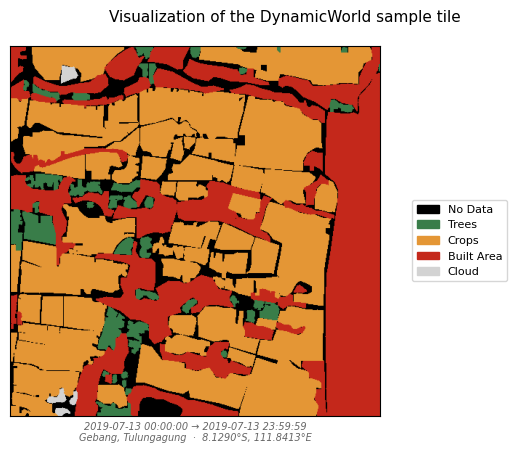

In [4]:
# https://doi.pangaea.de/10.1594/PANGAEA.933475
DW_CLASS_MAP = { 
    0: "No Data",
    1: "Water",
    2: "Trees",
    3: "Grass",
    4: "Flooded Vegetation",
    5: "Crops",
    6: "Scrub",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow and Ice",
    10: "Cloud",
}

DW_COLOR_MAP = {
    0: "#000000",
    1: "#419bdf",
    2: "#397d49",
    3: "#88b053",
    4: "#7a87c6",
    5: "#e49635",
    6: "#dfc35a",
    7: "#c4281b",
    8: "#a59b8f",
    9: "#f0f0f0",
    10: "#d3d3d3"
}

tile_path = "data/dw_label/dw_111.8412562864_-8.1289167721-20190713.tif"
tile = GeoTile.from_geotiff(tile_path).rebase(class_map=DW_CLASS_MAP, color_map=DW_COLOR_MAP)
tile.plot(title="Visualization of the DynamicWorld sample tile")
print("date: ", tile.datetime) # this is the anchor for date range

[########################################] | 100% Completed | 2.65 sms


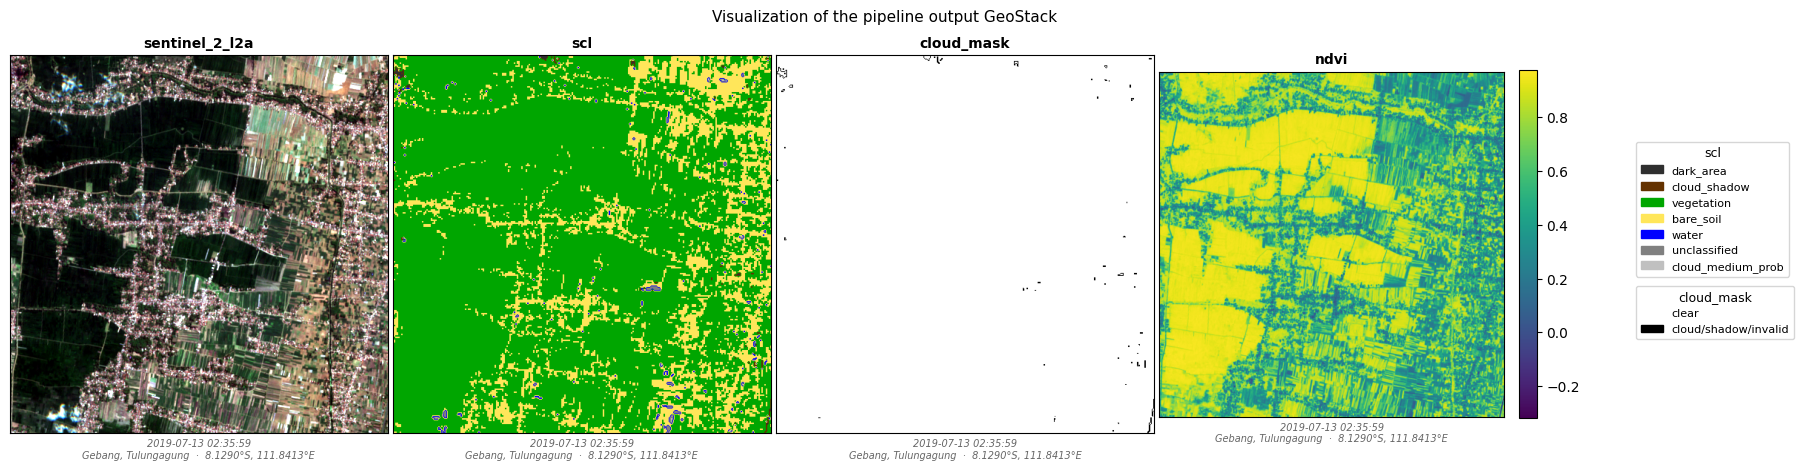

In [7]:
pipeline = Pipeline()

ingest_iter = pipeline.ingest(tile.to_anchor())

# This is a bit weird, but on inference, the request is AOI and date range
# Within that date range, it consist of multiple scenes, and the pipeline yields a GeoStack for each scene
# If we make a reference to a tiff files with datetime granularity of a day, 
# we know that first yielded GeoStack is the one we want

stack = next(ingest_iter)
stack.plot(title="Visualization of the pipeline output GeoStack");

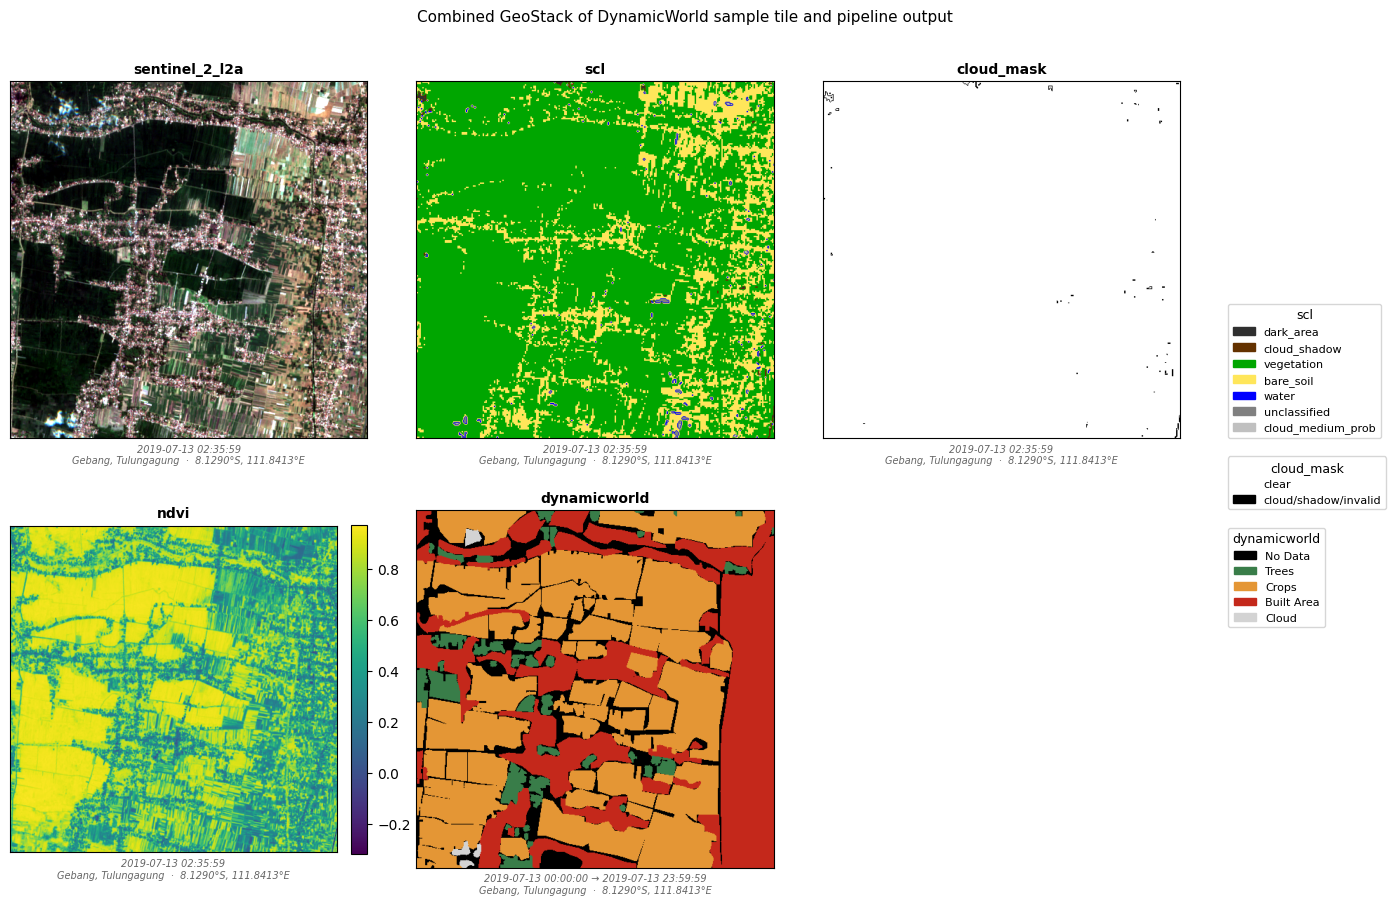

In [8]:
from geosave_engine.geodata import GeoStack

# you can append geotiles and geostack
# kwargs are layer names, values are GeoTile instances
combined_stack = GeoStack(stack, dynamicworld=tile) 
combined_stack.plot(
    title="Combined GeoStack of DynamicWorld sample tile and pipeline output", cols=3
);

In [9]:
# you can save geostack to .zarr file
# open-source data storage format designed for large, multi-dimensional numerical arrays (tensors)

combined_stack.to_zarr("data/dw_dataset/combined_stack.zarr")

geostack = GeoStack.from_zarr("data/dw_dataset/combined_stack.zarr")
geostack

GeoStack(cloud_mask=GeoTile(bbox=(590130.0, 9098800.0, 595230.0, 9103900.0), crs='EPSG:32749', datetime=2019-07-13 02:35:59.024000, metadata={'metadata': {'description': 'Cloud/shadow/invalid mask from Scene Classification Layer (SCL)'}}, bands=(), shape=(510, 510)), dynamicworld=GeoTile(bbox=(590130.0, 9098800.0, 595230.0, 9103900.0), crs='EPSG:32749', datetime=2019-07-13 00:00:00–2019-07-13 23:59:59.999999, metadata={}, bands=('band_1',), shape=(1, 510, 510)), ndvi=GeoTile(bbox=(590130.0, 9098800.0, 595230.0, 9103900.0), crs='EPSG:32749', datetime=2019-07-13 02:35:59.024000, metadata={'metadata': {'description': 'Normalized Difference Vegetation Index'}}, bands=(), shape=(510, 510)), scl=GeoTile(bbox=(590130.0, 9098800.0, 595230.0, 9103900.0), crs='EPSG:32749', datetime=2019-07-13 02:35:59.024000, metadata={'metadata': {'description': 'Sentinel-2 L2A Scene Classification Layer (Sen2Cor)'}}, bands=(), shape=(510, 510)), sentinel_2_l2a=GeoTile(bbox=(590130.0, 9098800.0, 595230.0, 91039

#### Building Dataset

Use pipeline to build dataset for offline training

In [10]:
from pathlib import Path

pipeline = Pipeline()

for p in Path("data/dw_label").rglob("*.tif"):
    dw = GeoTile.from_geotiff(p).rebase(plot_meta={"class_map": DW_CLASS_MAP, "color_map": DW_COLOR_MAP})
    stack = next(pipeline.ingest(dw.to_anchor()))
    combined_stack = GeoStack(stack, dynamicworld=dw)
    combined_stack.to_zarr(f"data/dw_dataset/{p.stem}.zarr")

[########################################] | 100% Completed | 2.95 sms
[########################################] | 100% Completed | 4.76 sms
[########################################] | 100% Completed | 3.65 sms


#### Ingest for Inference

For inference you can directly create the tensor for your model without needing torch Dataset

In [11]:
from geosave_engine.geodata.pipeline import source_from_dict

api_request ={
    'type': 'coordinate',
    'lat': -6.2088,
    'lon': 106.8456,
    'datetime': '2026-01', # lets query for the entirity of January 2026
    'area_m': 10000,
    'resolution': 10,
    'tile_size_px': 500 # autimatically chunk the request into 500x500 px, so the ingestion is not too huge crashing system memory
}

source = source_from_dict(api_request)
anchors = list(source.to_anchors())
anchors

[GeoAnchor(bbox=(699207.1688564329, 9313358.339245755, 704207.1688564329, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(704207.1688564329, 9313358.339245755, 709207.1688564329, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(699207.1688564329, 9308358.339245755, 704207.1688564329, 9313358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(704207.1688564329, 9308358.339245755, 709207.1688564329, 9313358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={})]

In [12]:
# first chunk from the anchor, 
# tiles for the whole month of January 2026, ready for model forward
model_ctx = list(pipeline.ingest_to_tensor(anchors[0]))

print("Number of scenes in the anchor:", len(model_ctx))
model_ctx[0]  # first sample's context dict, ready for model forward

[########################################] | 100% Completed | 9.75 sms
[########################################] | 100% Completed | 7.60 sms
[########################################] | 100% Completed | 5.57 sms
[########################################] | 100% Completed | 18.85 ss
[########################################] | 100% Completed | 10.74 ss
[########################################] | 100% Completed | 9.01 sms
Number of scenes in the anchor: 6


{'sentinel_2_l2a': tensor([[[[8262, 8263, 8264,  ..., 8244, 8245, 8245],
           [8263, 8263, 8264,  ..., 8243, 8244, 8245],
           [8263, 8264, 8264,  ..., 8243, 8243, 8244],
           ...,
           [8275, 8276, 8278,  ..., 8200, 8199, 8198],
           [8275, 8277, 8279,  ..., 8200, 8200, 8199],
           [8276, 8278, 8280,  ..., 8201, 8201, 8200]],
 
          [[8321, 8305, 8318,  ..., 8293, 8295, 8281],
           [8303, 8314, 8341,  ..., 8282, 8301, 8320],
           [8319, 8318, 8328,  ..., 8285, 8308, 8316],
           ...,
           [8325, 8332, 8349,  ..., 8238, 8217, 8234],
           [8312, 8348, 8367,  ..., 8233, 8228, 8219],
           [8336, 8340, 8361,  ..., 8230, 8225, 8224]],
 
          [[8260, 8258, 8266,  ..., 8230, 8233, 8233],
           [8280, 8282, 8268,  ..., 8236, 8241, 8241],
           [8260, 8249, 8252,  ..., 8256, 8255, 8245],
           ...,
           [8259, 8264, 8270,  ..., 8195, 8182, 8172],
           [8261, 8248, 8262,  ..., 8183, 8184, 

In [13]:
from geosave_engine.geodata.datasets import stack_samples

# lets stack the samples into a single batch for model forward
input_tensor = stack_samples(model_ctx)
input_tensor.keys()

dict_keys(['sentinel_2_l2a', 'latlon', 'time', 'scl', 'ndvi', 'temporal_coords', 'geobox', 'location_coords', 'geotags', 'cloud_mask'])

In [14]:
input_tensor["sentinel_2_l2a"].shape  # (batch, temporal, band, y, x) only one scene per sample

torch.Size([6, 1, 12, 500, 500])

In [17]:
# All context tensors are stacked into a single batch, ready for model forward
print(input_tensor["temporal_coords"])  # (batch, 2) (year, day_of_year)
print(input_tensor["location_coords"])  # (batch, 2) (lat, lon)

tensor([[[2.0260e+03, 2.0000e+00]],

        [[2.0260e+03, 7.0000e+00]],

        [[2.0260e+03, 1.2000e+01]],

        [[2.0260e+03, 1.7000e+01]],

        [[2.0260e+03, 2.2000e+01]],

        [[2.0260e+03, 2.7000e+01]]])
tensor([[ -6.1863, 106.8229],
        [ -6.1863, 106.8229],
        [ -6.1863, 106.8229],
        [ -6.1863, 106.8229],
        [ -6.1863, 106.8229],
        [ -6.1863, 106.8229]])
